# Feature Analysis

This notebook provides a quantitative analysis of the performance features engineered in the previous step. Through comparative bar charts and delta plots, it identifies distinct differences between teammates regarding speed, braking behavior, throttle application, and gear management across each corner. Additionally, it explores correlations between different performance metrics to uncover the relationship between driving style and speed.

## Setup and Dependencies

Load dependencies, configure the notebook path, and prepare the modules used in the exploration steps.

In [1]:
import sys
import fastf1
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.config import *
from src.load_save_data import *
from src.preprocess_data import *
from src.explore_data import *
from src.feature_engineering import *

## Load Processed Data

Fetch cleaned interpolated telemetry data and newly added features for both teammates. 

In [2]:
session = fastf1.get_session(YEAR, GRAND_PRIX, "Q")
session.load()

driver_1, driver_2 = get_drivers(session, TEAM)
segment = get_segment(session, driver_1, driver_2)
turns = get_turns(session)

try:
    lap_1, lap_2 = load_cache(YEAR, GRAND_PRIX, segment, driver_1, driver_2)
except Exception as e:
    print(f"Processed data for {YEAR} {GRAND_PRIX} {driver_1} and {driver_2} not found: {e}")

req         WARNING 	DEFAULT CACHE ENABLED! (49.81 MB) C:\Users\joseg\AppData\Local\Temp\fastf1
core           INFO 	Loading data for Japanese Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '81', '16', '63', '12', '6', '44', '23', '87', '10', '55', '14', '30', '22', '27', '5', '31', '7', '18']



Processed data for 2025 Japanese Grand Prix ALO and STR found in cache.
Driver 1: ALO, Driver 2: STR, Segment: Q1


## Segments' Time Analysis

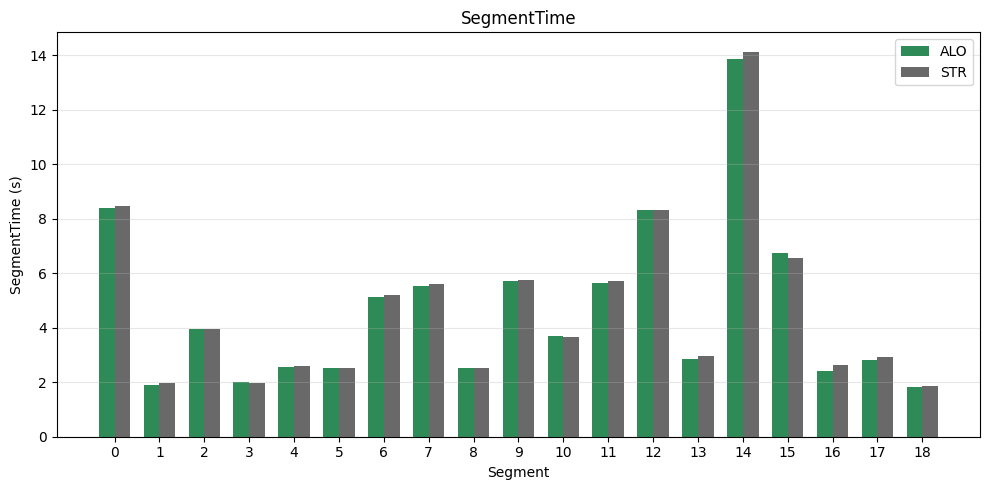

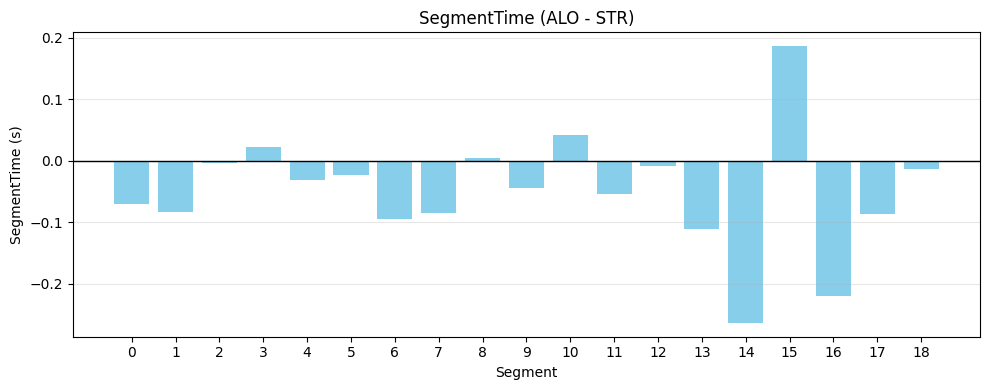

In [3]:
fig = barplot_feature_comparison(lap_1, lap_2, "SegmentTime", y_unit="s")
save_figure(fig, "features", "comparison", "SegmentTime", YEAR, GRAND_PRIX, TEAM, driver_1, driver_2)
fig = barplot_feature_delta(lap_1, lap_2, "SegmentTime", y_unit="s")
save_figure(fig, "features", "delta", "SegmentTime", YEAR, GRAND_PRIX, TEAM, driver_1, driver_2)

## Segments' Speed Features Analysis

Evaluate performance by comparing entry, minimum, and exit speeds for each turn. These visualizations highlight differences in cornering technique, identifying where one driver carries more speed or optimizes their line compared to their teammate.

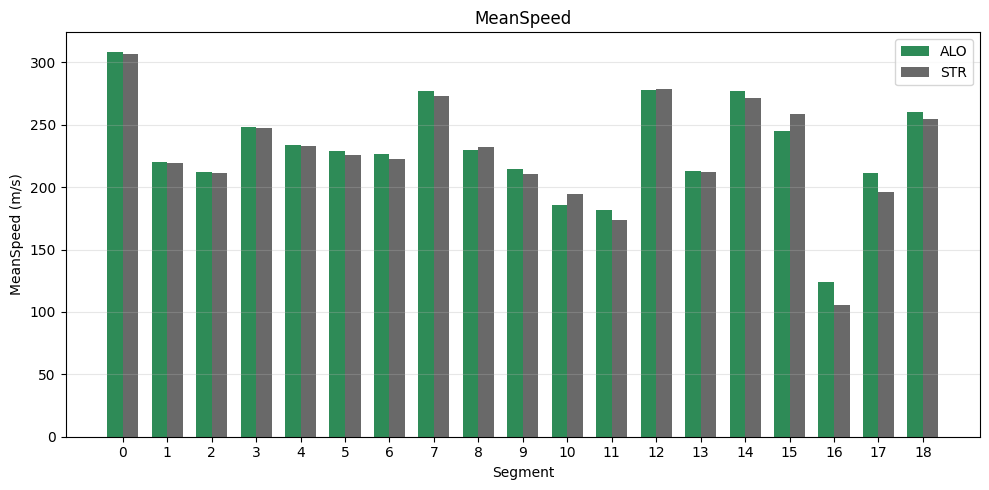

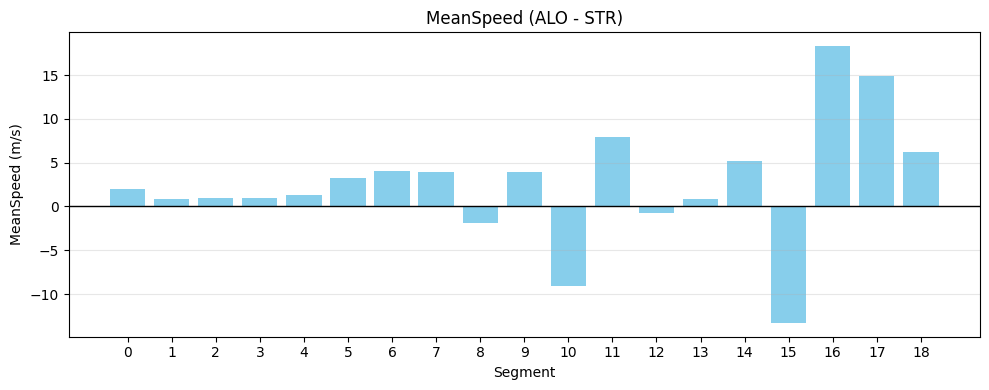

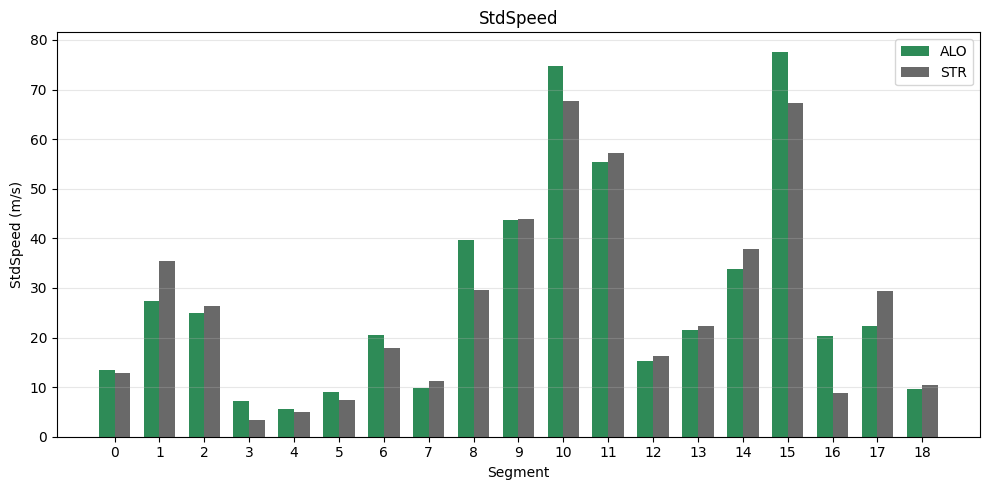

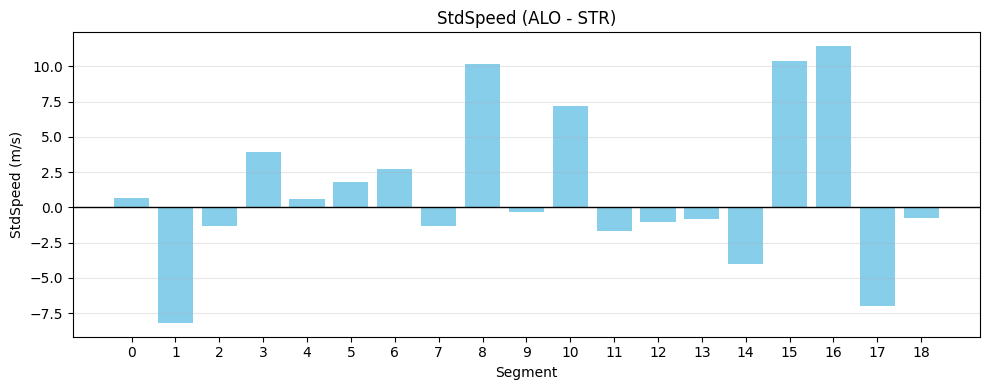

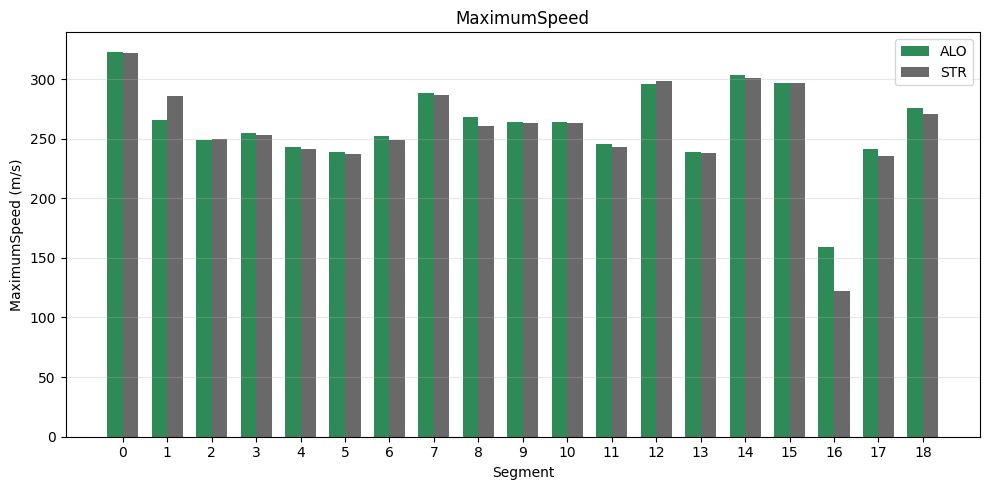

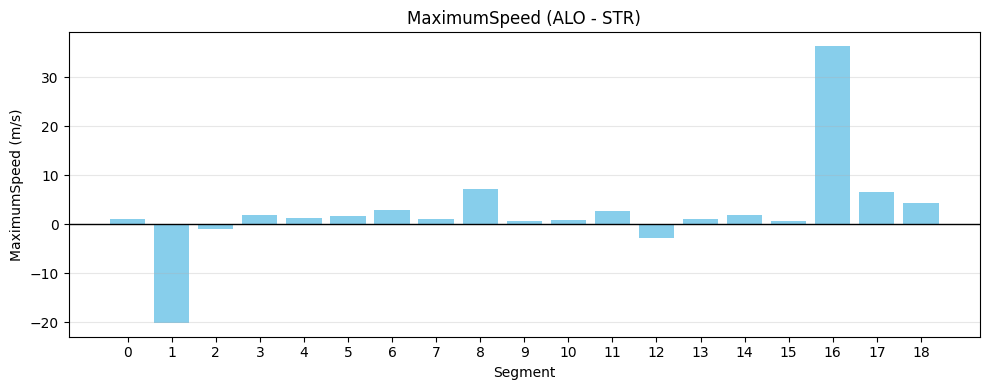

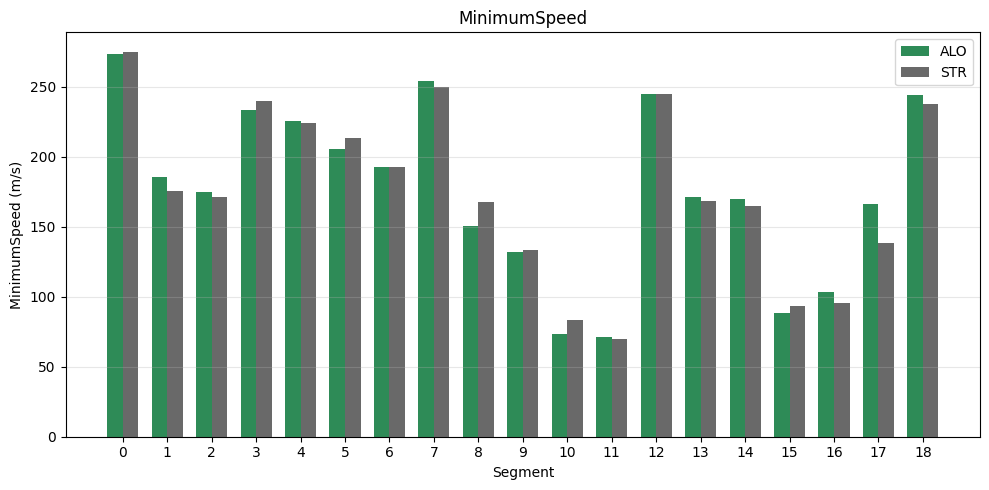

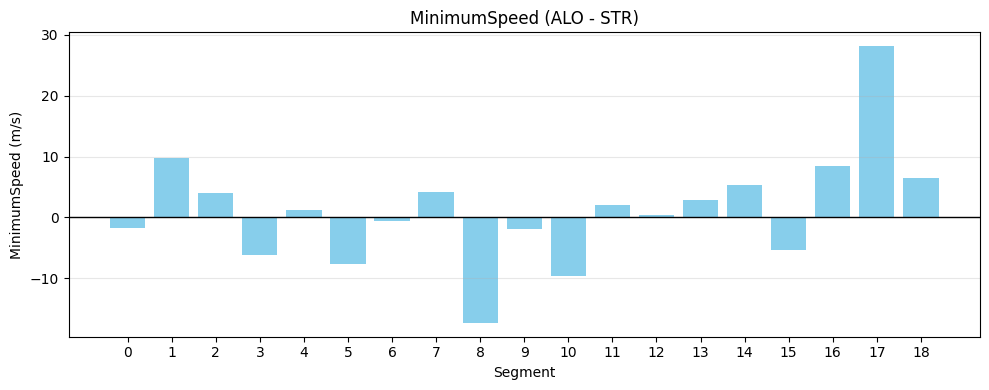

In [4]:
for feature in ["MeanSpeed", "StdSpeed", "MaximumSpeed", "MinimumSpeed"]:
    fig = barplot_feature_comparison(lap_1, lap_2, feature, "m/s")
    save_figure(fig, "features", "comparison", f"{feature.lower()}", YEAR, GRAND_PRIX, TEAM, driver_1, driver_2)
    fig = barplot_feature_delta(lap_1, lap_2, feature, "m/s")
    save_figure(fig, "features", "delta", f"{feature.lower()}", YEAR, GRAND_PRIX, TEAM, driver_1, driver_2)

## Segments' Throttle Features  Analysis

Compare mean and standard deviation of throttle usage, as well as the percentage of the segment spent at full throttle. These charts visualize traction management and power deployment differences upon corner exit.

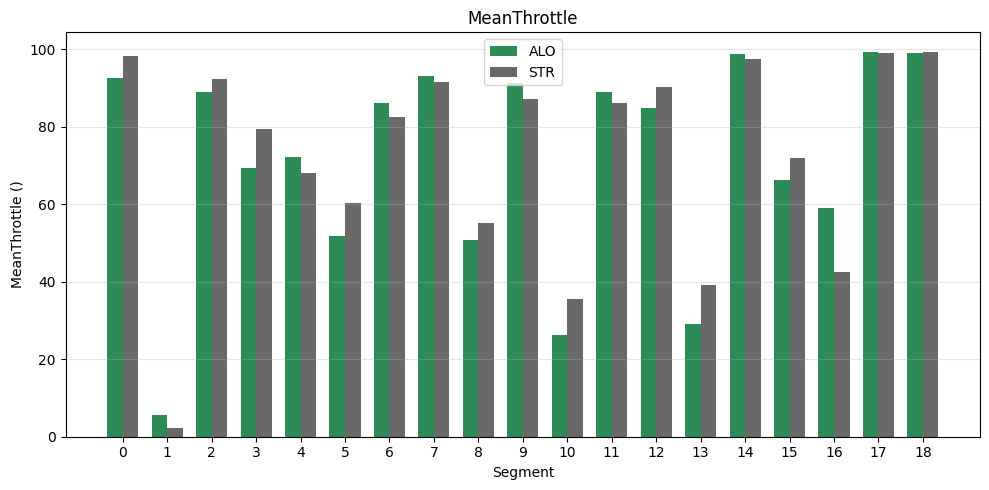

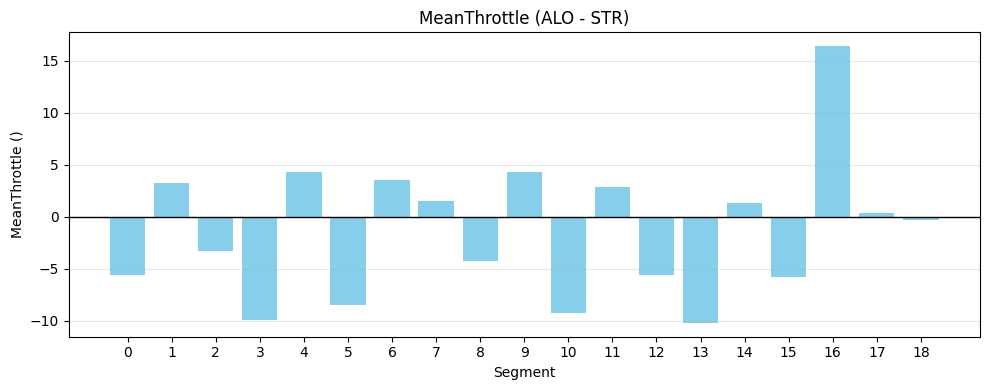

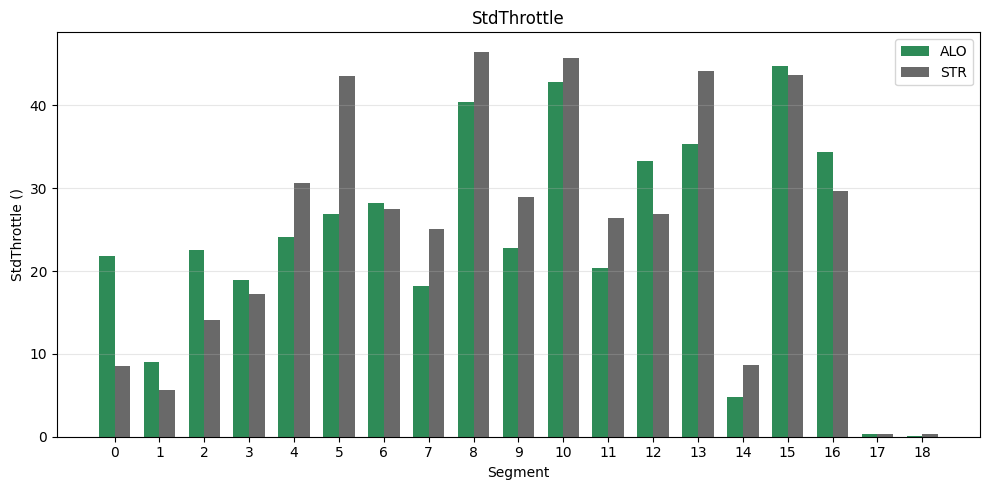

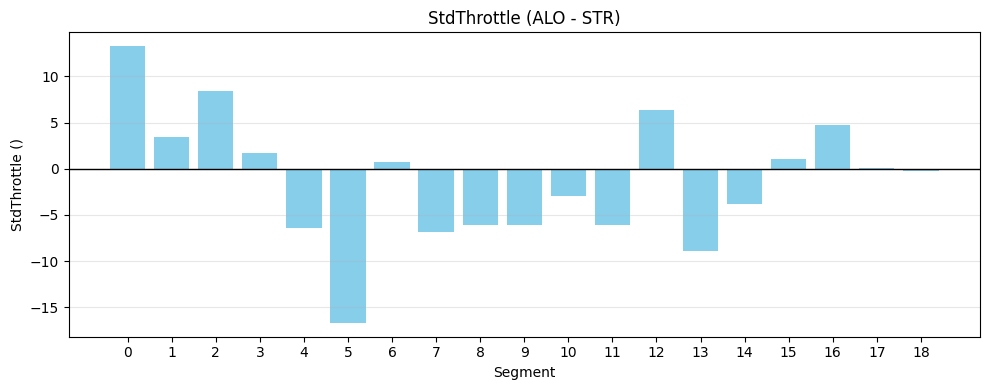

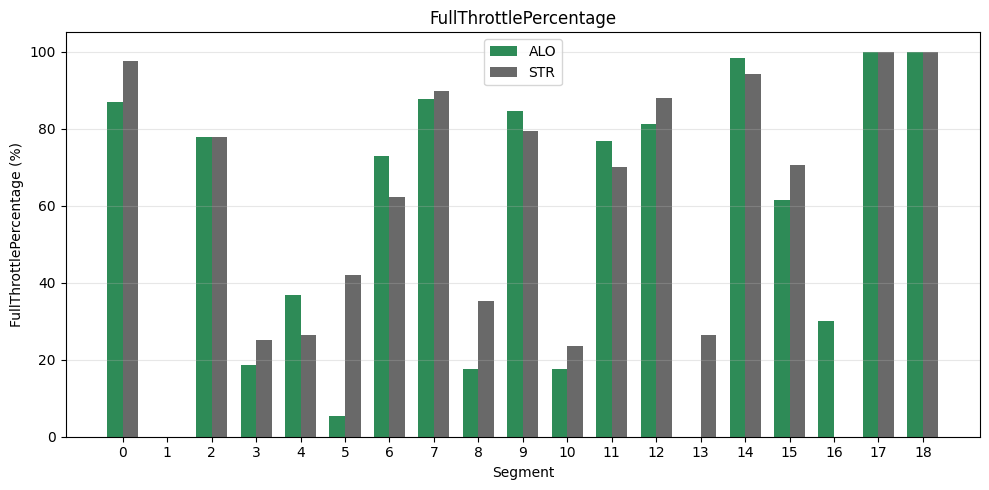

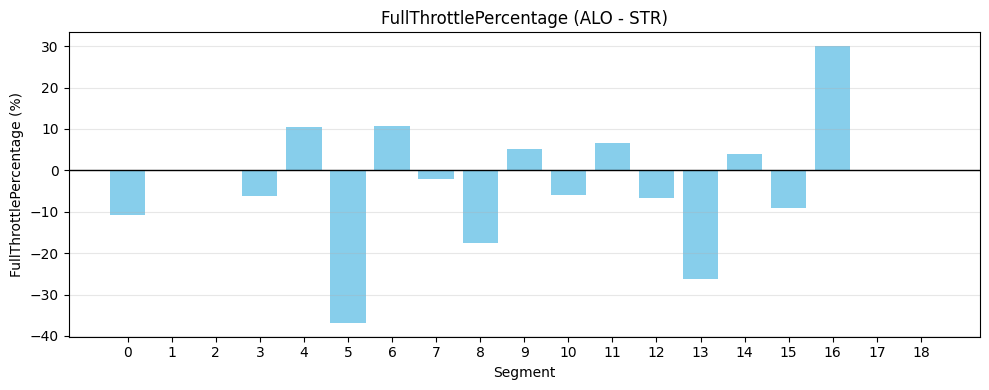

In [5]:
for feature, y_unit in [("MeanThrottle", ""), ("StdThrottle", ""), ("FullThrottlePercentage", "%")]:
    fig = barplot_feature_comparison(lap_1, lap_2, feature, y_unit=y_unit)
    save_figure(fig, "features", "comparison", f"{feature.lower()}", YEAR, GRAND_PRIX, TEAM, driver_1, driver_2)
    fig = barplot_feature_delta(lap_1, lap_2, feature, y_unit=y_unit)
    save_figure(fig, "features", "delta", f"{feature.lower()}", YEAR, GRAND_PRIX, TEAM, driver_1, driver_2)

## Segments' Gear Shift Features Analysis

Examine transmission-related data, including the number of gear shifts, gear range (highest/lowest gear used), and engine RPM statistics. This identifies variations in gear selection strategies and how each driver manages power through different sections of the track.

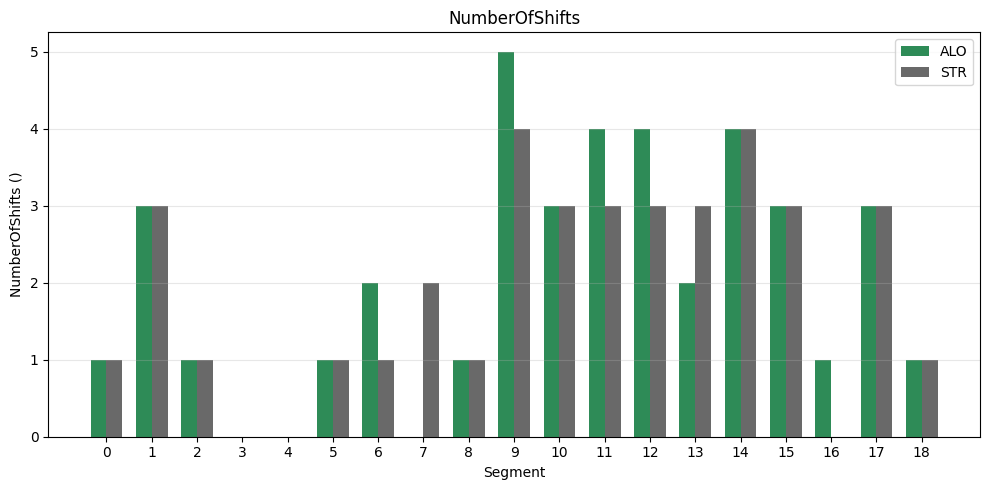

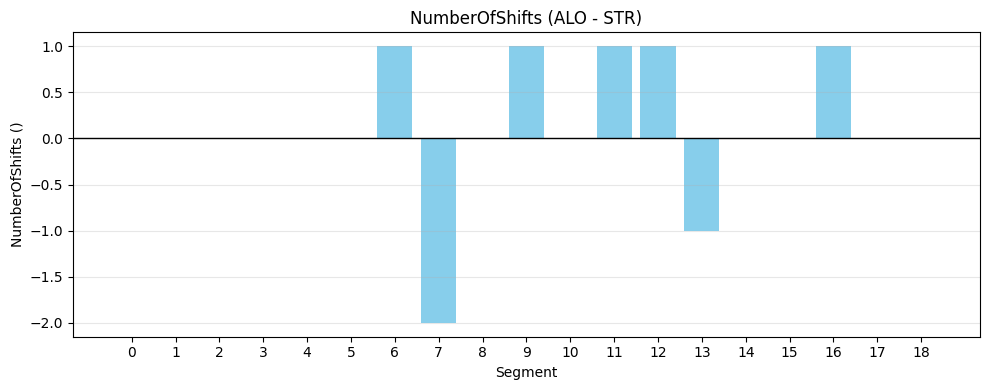

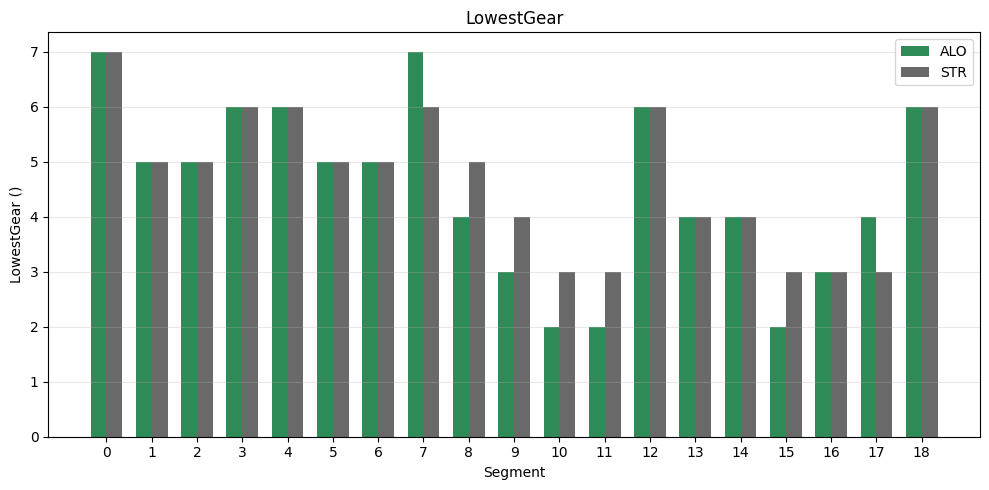

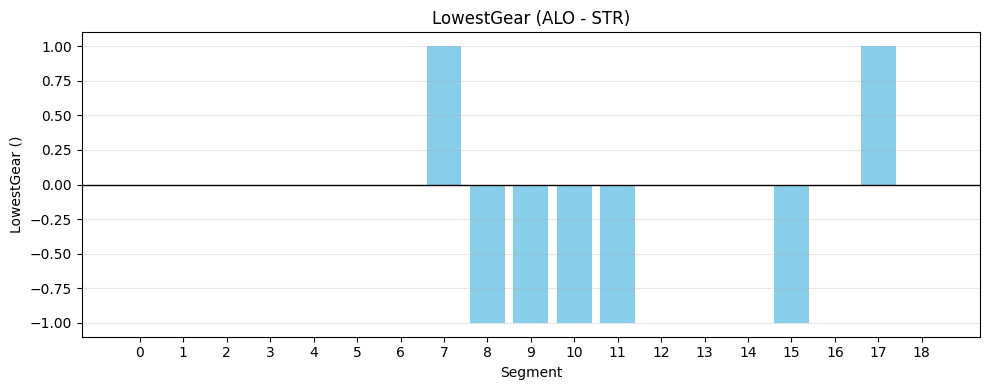

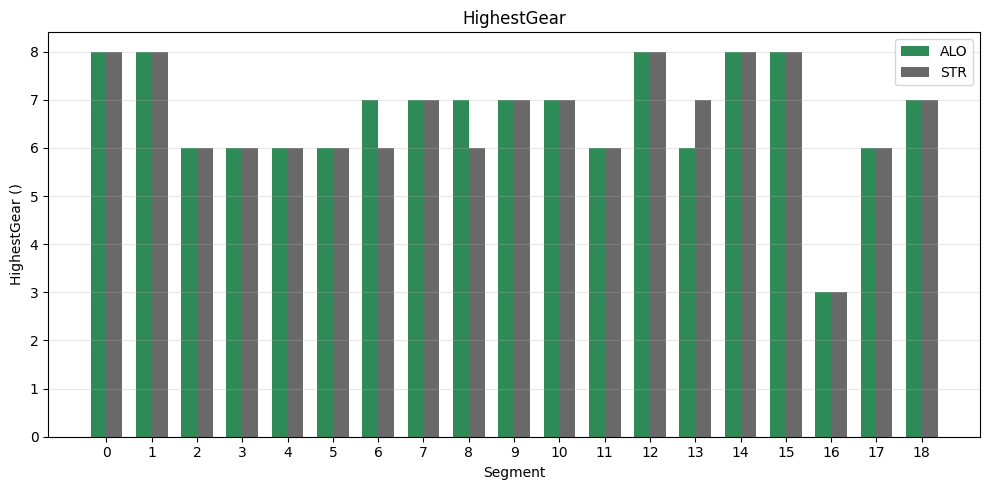

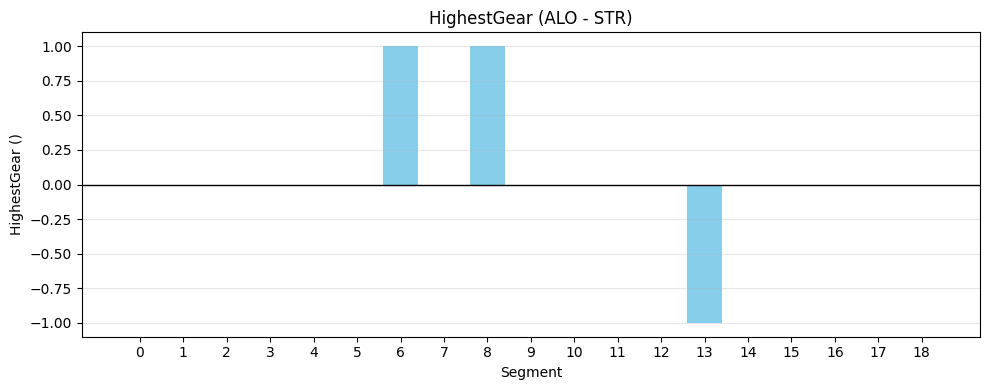

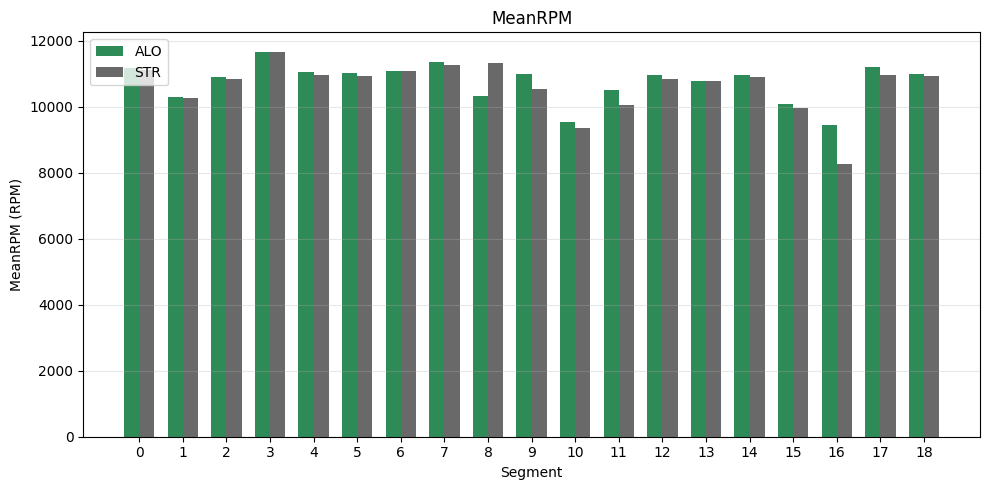

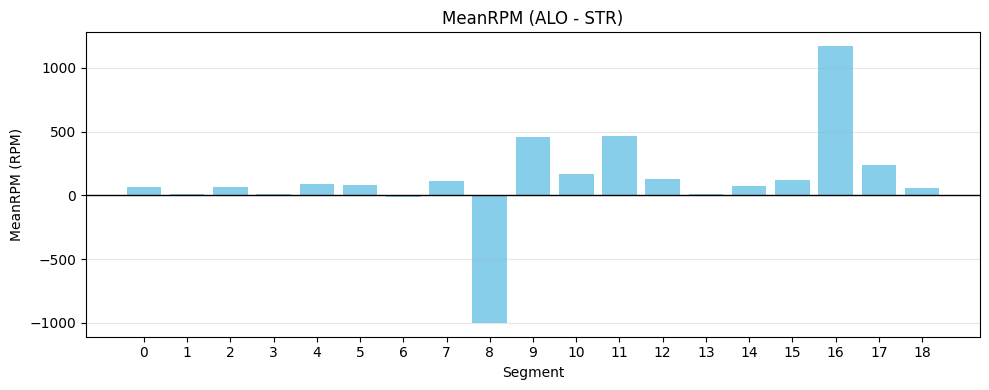

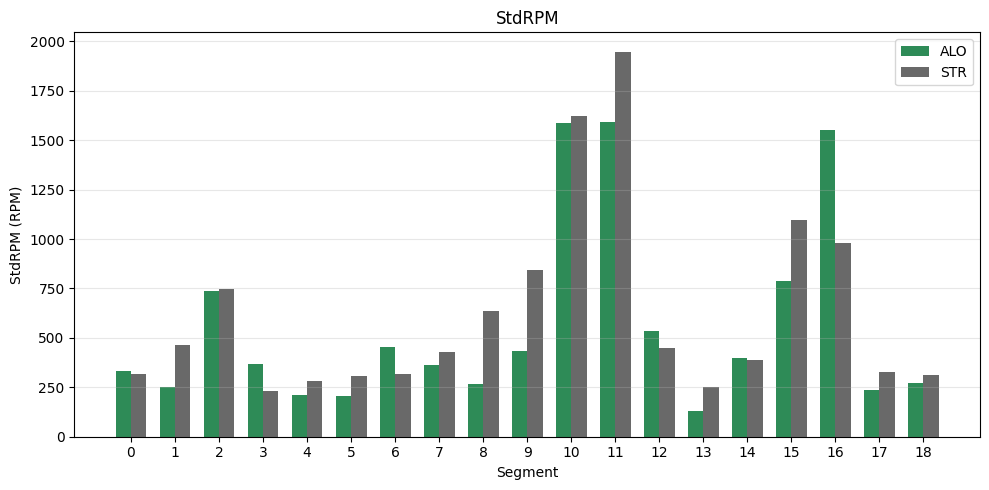

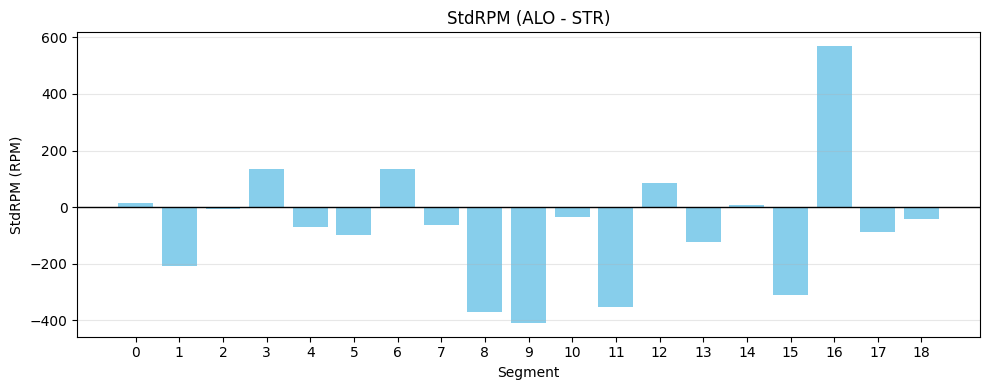

In [6]:
for feature, y_unit in [("NumberOfShifts", ""), ("LowestGear", ""), ("HighestGear", ""), ("MeanRPM", "RPM"), ("StdRPM", "RPM")]:
    fig = barplot_feature_comparison(lap_1, lap_2, feature, y_unit=y_unit)
    save_figure(fig, "features", "comparison", f"{feature.lower()}", YEAR, GRAND_PRIX, TEAM, driver_1, driver_2)
    fig = barplot_feature_delta(lap_1, lap_2, feature, y_unit=y_unit)
    save_figure(fig, "features", "delta", f"{feature.lower()}", YEAR, GRAND_PRIX, TEAM, driver_1, driver_2)

## Turns' Time Analysis

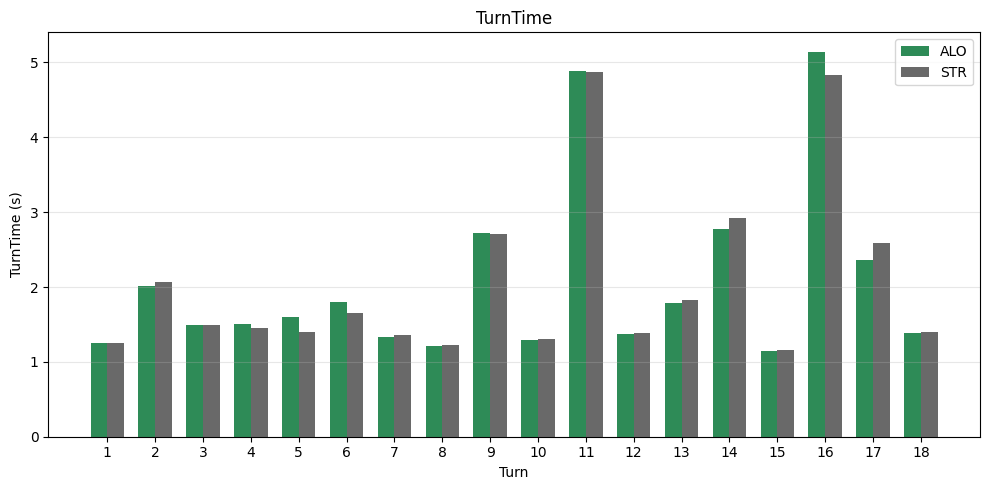

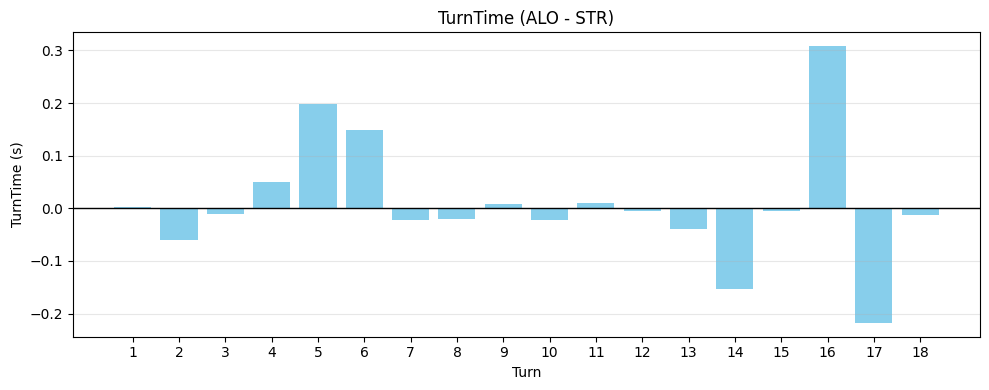

In [7]:
fig = barplot_feature_comparison(lap_1, lap_2, "TurnTime", y_unit="s")
save_figure(fig, "features", "comparison", "TurnTime", YEAR, GRAND_PRIX, TEAM, driver_1, driver_2)
fig = barplot_feature_delta(lap_1, lap_2, "TurnTime", y_unit="s")
save_figure(fig, "features", "delta", "TurnTime", YEAR, GRAND_PRIX, TEAM, driver_1, driver_2)

## Turns' Speed Features Analysis

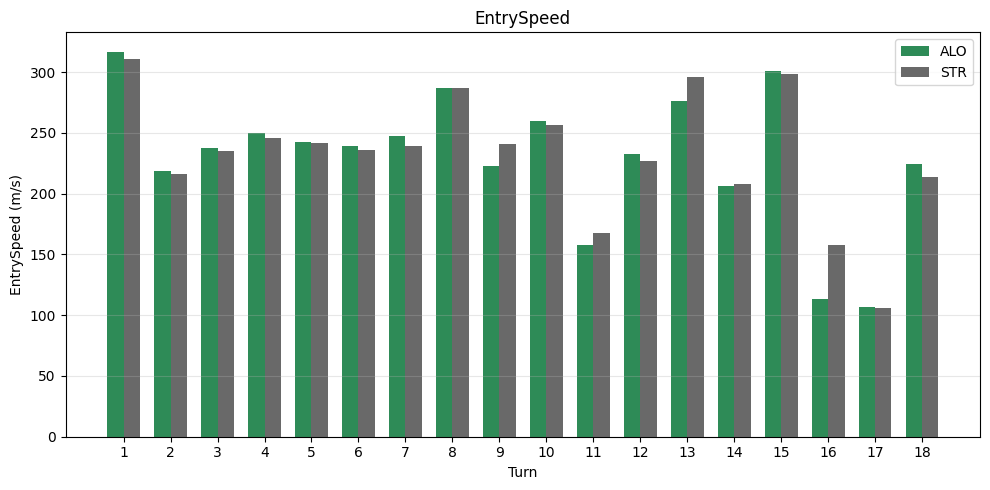

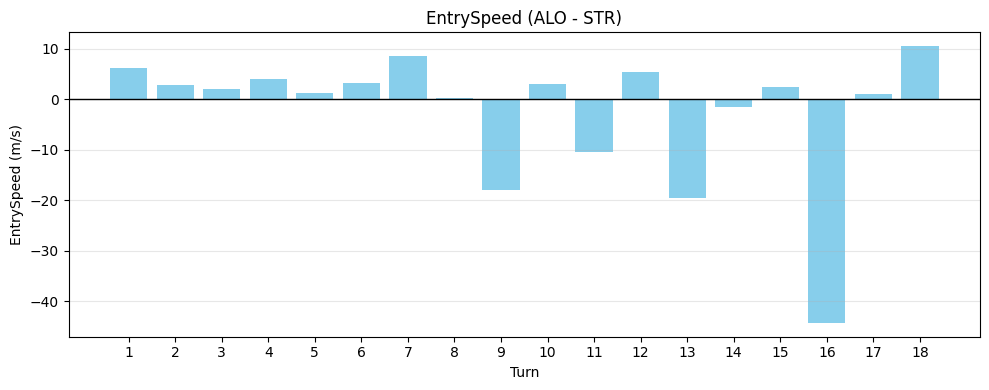

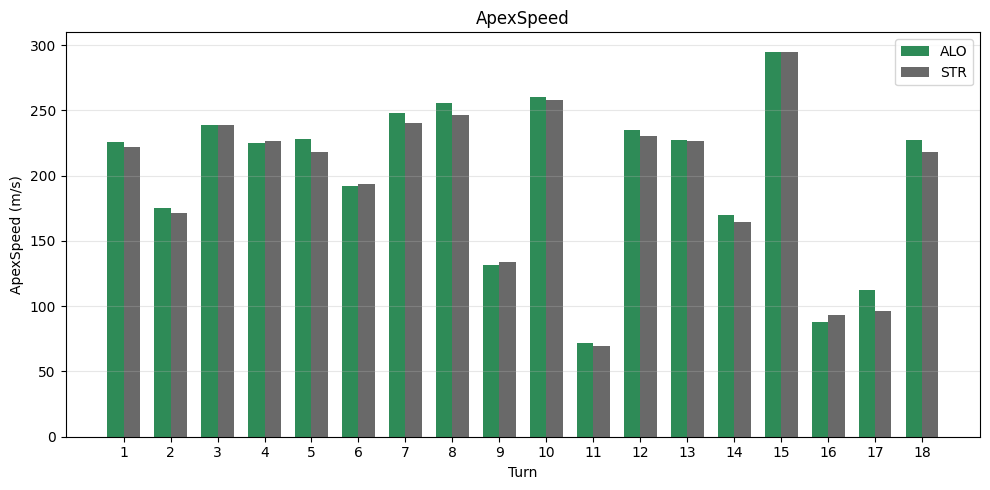

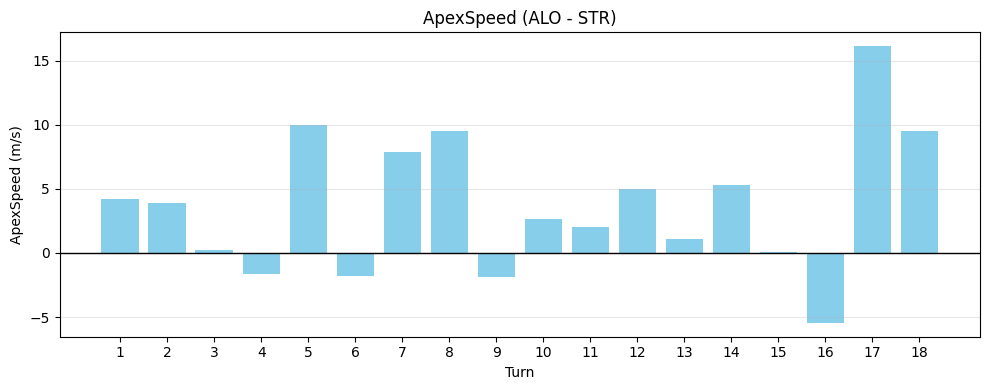

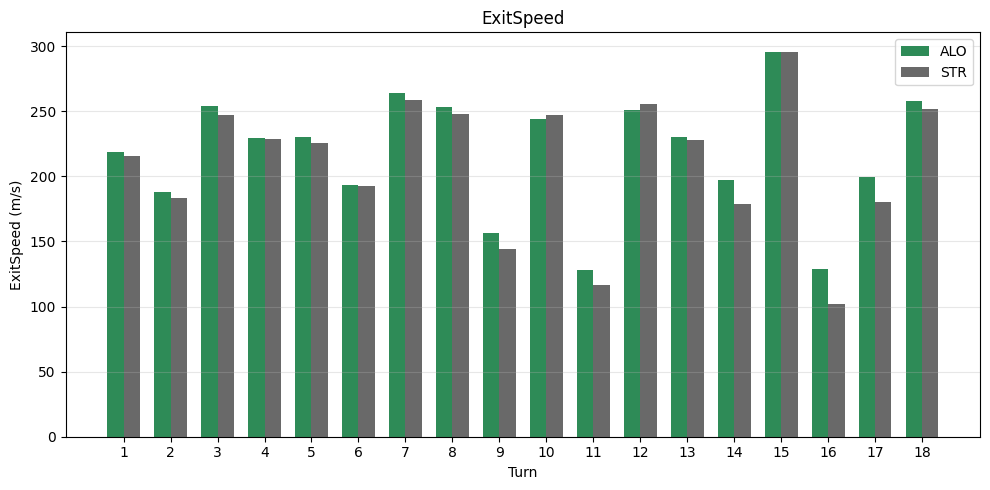

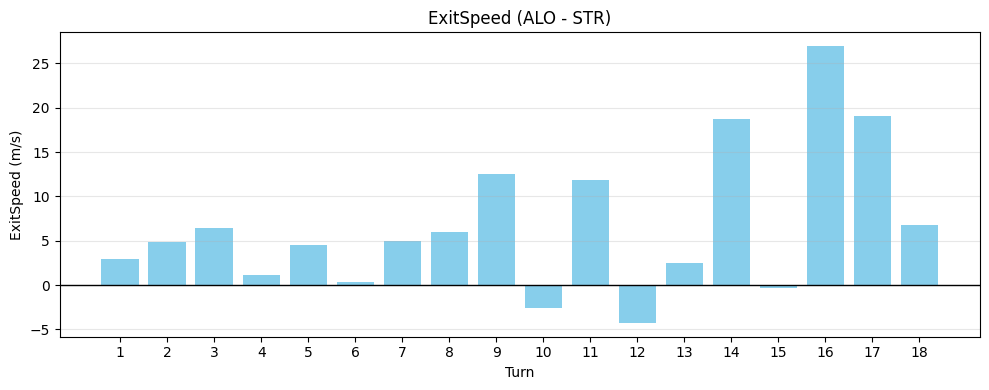

In [8]:
for feature in ["EntrySpeed", "ApexSpeed", "ExitSpeed"]:
    fig = barplot_feature_comparison(lap_1, lap_2, feature, y_unit="m/s")
    save_figure(fig, "features", "comparison", f"{feature.lower()}", YEAR, GRAND_PRIX, TEAM, driver_1, driver_2)
    fig = barplot_feature_delta(lap_1, lap_2, feature, y_unit="m/s")
    save_figure(fig, "features", "delta", f"{feature.lower()}", YEAR, GRAND_PRIX, TEAM, driver_1, driver_2)

## Turns' Braking Features Analysis

Analyze differences in braking points and duration. This section helps identify which driver commits more aggressively to corner entry and how braking behavior impacts overall lap time.

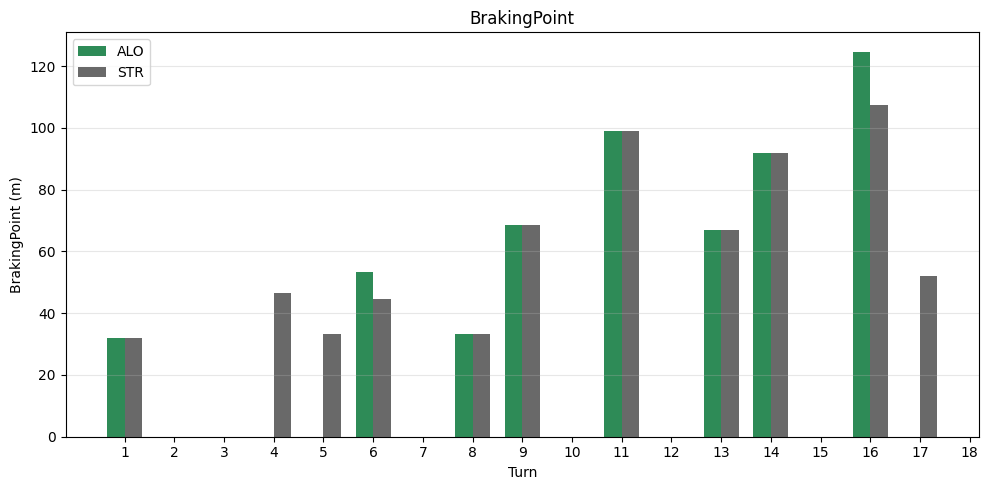

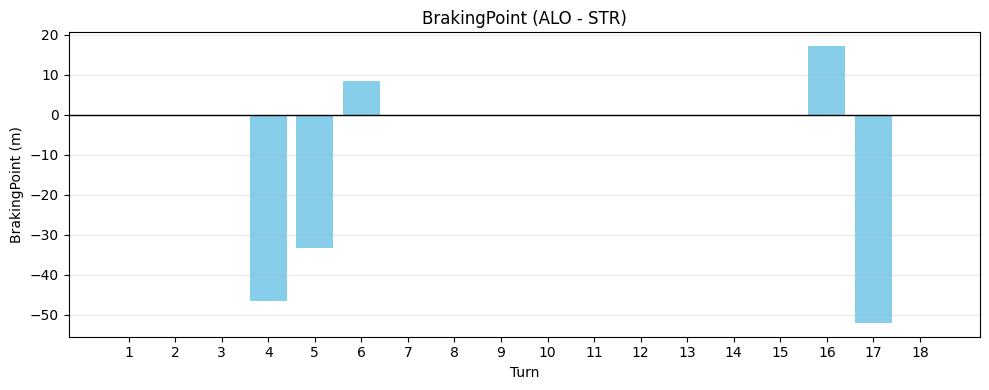

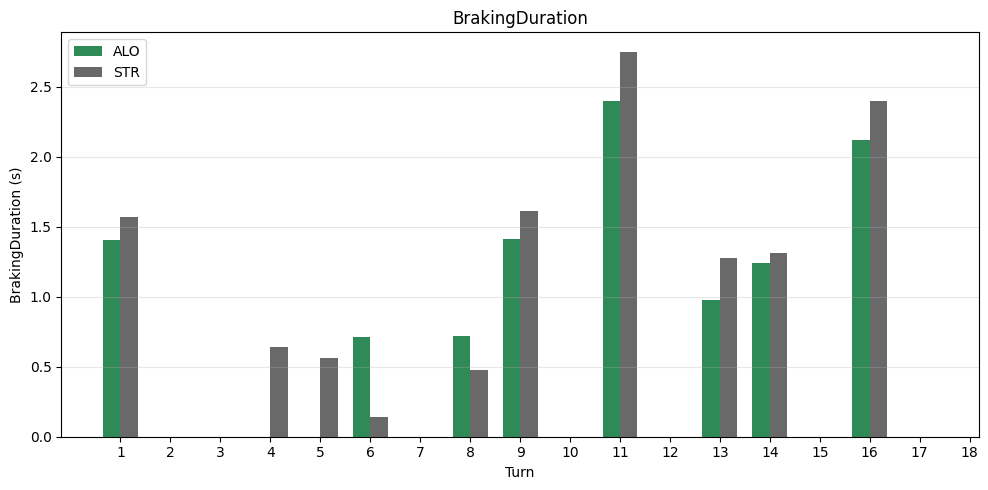

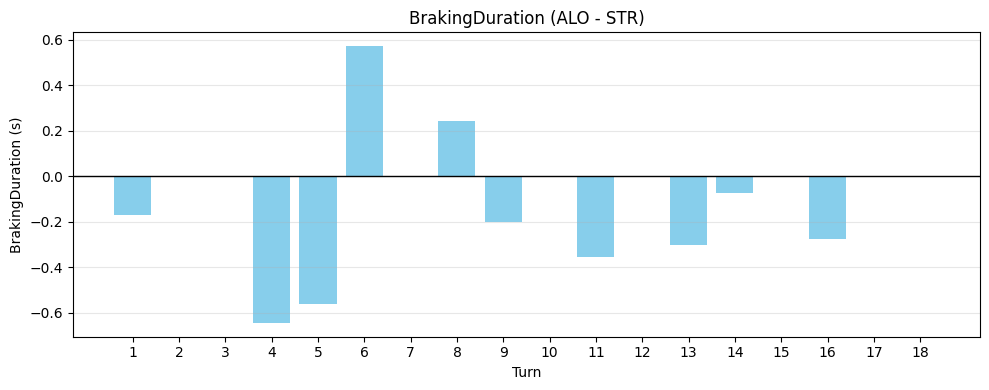

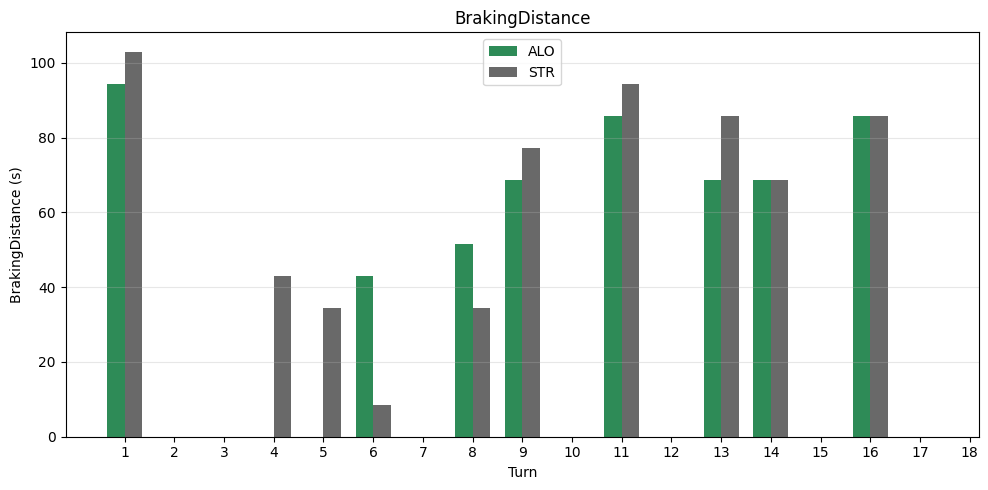

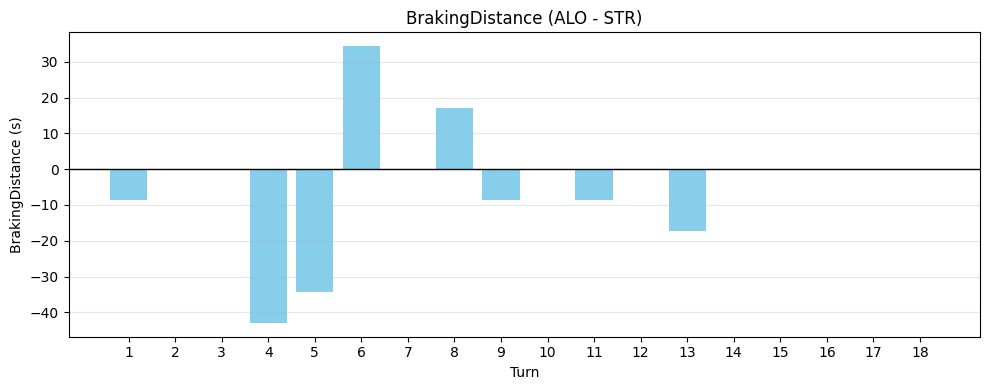

In [9]:
for feature in ["BrakingPoint", "BrakingDuration", "BrakingDistance"]:
    fig = barplot_feature_comparison(lap_1, lap_2, feature, y_unit="m" if feature == "BrakingPoint" else "s")
    save_figure(fig, "features", "comparison", f"{feature.lower()}", YEAR, GRAND_PRIX, TEAM, driver_1, driver_2)
    fig = barplot_feature_delta(lap_1, lap_2, feature, y_unit="m" if feature == "BrakingPoint" else "s")
    save_figure(fig, "features", "delta", f"{feature.lower()}", YEAR, GRAND_PRIX, TEAM, driver_1, driver_2)

## Segments' Features and Time Correlation Analysis

Segment features correlation with Segment Time:


,FeatureX,FeatureY,Pearson,PearsonP,Spearman,SpearmanP
0,MeanSpeed,SegmentTime,-0.740253,0.000290,-0.656140,0.002282
1,MeanThrottle,SegmentTime,-0.557295,0.013179,-0.492982,0.031982
2,MinimumSpeed,SegmentTime,-0.470062,0.042270,-0.654386,0.002367
3,StdRPM,SegmentTime,-0.452480,0.051751,-0.166667,0.495266
4,LowestGear,SegmentTime,-0.441683,0.058325,-0.513092,0.024664
5,FullThrottlePercentage,SegmentTime,-0.391439,0.097457,-0.424674,0.069933
6,MaximumRPM,SegmentTime,-0.368096,0.120999,-0.228271,0.347243
7,StdSpeed,SegmentTime,0.352476,0.138850,0.419298,0.073937
8,MeanRPM,SegmentTime,-0.341836,0.152015,-0.045614,0.852896
9,MaximumSpeed,SegmentTime,-0.332014,0.164913,-0.331579,0.165502


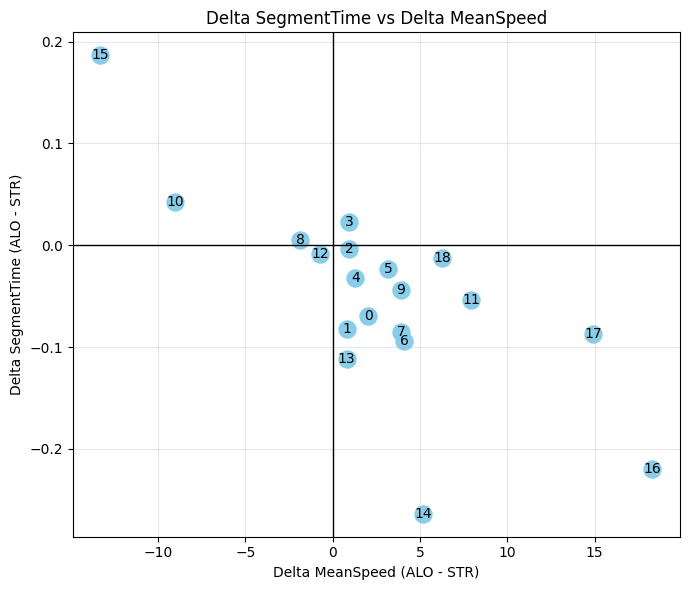

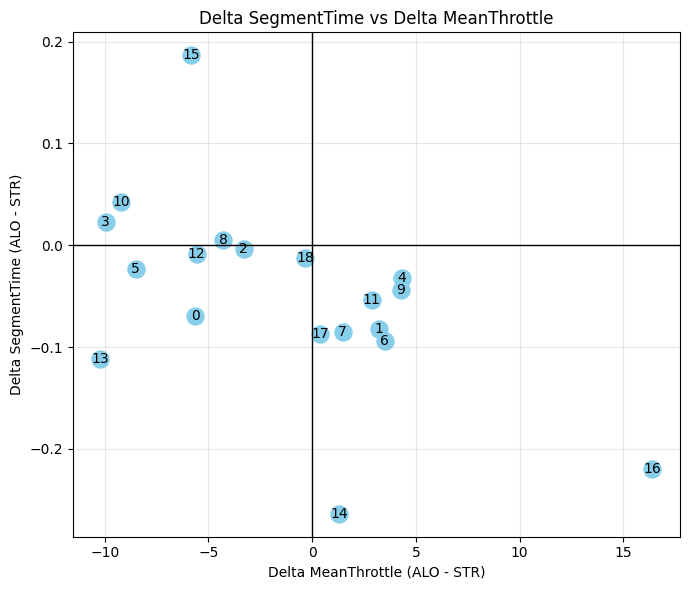

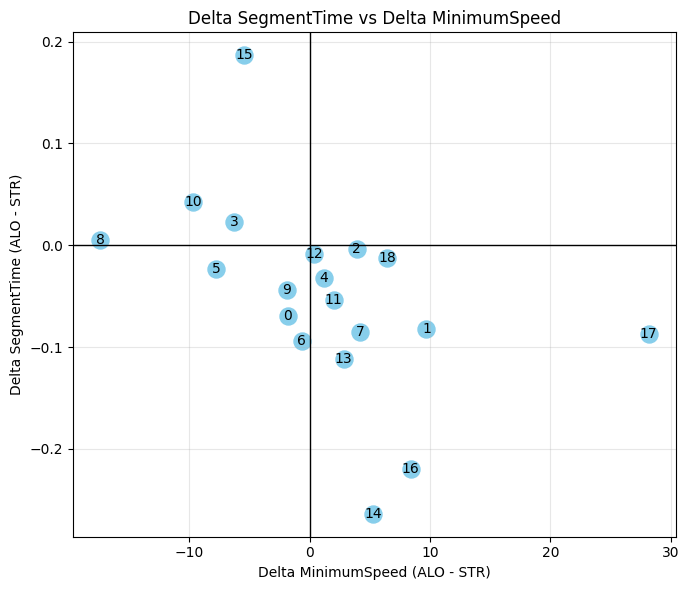

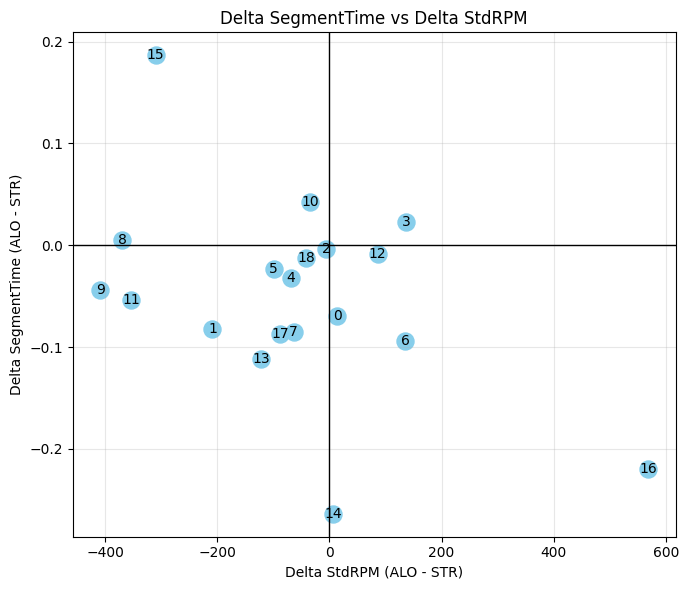

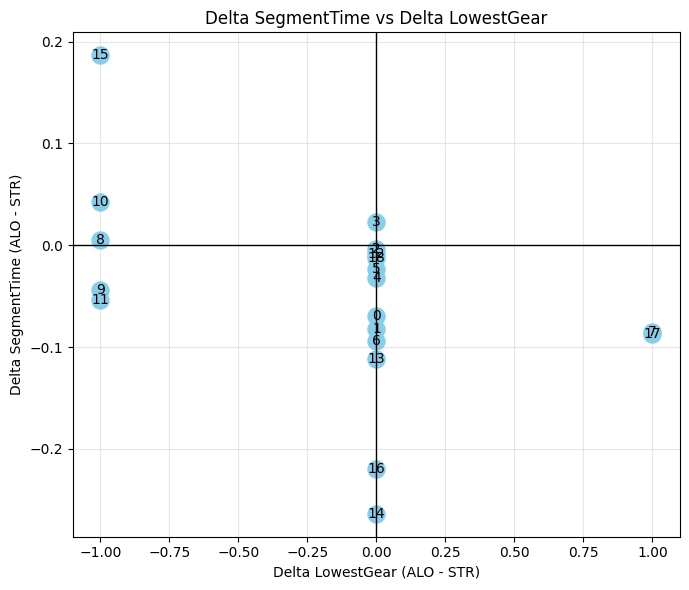

In [10]:
segment_features = [
    column
    for column in lap_1["Segments"].columns
    if column not in ["Segment", "SegmentTime"]
]

segment_time_correlations = []

for feature in segment_features:

    segment_time_correlations.append(
        calculate_feature_correlation(
            lap_1,
            lap_2,
            feature,
            "SegmentTime",
        )
    )

segment_time_correlations = (
    pd.concat(segment_time_correlations, ignore_index=True)
    .sort_values("Pearson", key=lambda s: s.abs(), ascending=False)
    .reset_index(drop=True)
)

print(f"Segment features correlation with Segment Time:")
display(segment_time_correlations)
save_dataframe(
    segment_time_correlations,
    "SegmentTimeCorrelations",
    YEAR,
    GRAND_PRIX,
    TEAM,
)

top_features = segment_time_correlations.head(5)["FeatureX"].tolist()

for feature in top_features:

    fig = scatterplot_features_relationship(
        lap_1,
        lap_2,
        feature,
        "SegmentTime",
    )

    save_figure(
        fig,
        "features",
        "relationship",
        f"{feature.lower()}_segmenttime",
        YEAR,
        GRAND_PRIX,
        TEAM,
        driver_1,
        driver_2,
    )

## Segments' Features Correlation Analysis

Investigate relationships between different performance metrics . Scatter plots here reveal how specific driving styles like early braking or throttle modulation correlate with exit speed and overall corner performance.

,FeatureX,FeatureY,Pearson,PearsonP,Spearman,SpearmanP
0,MaximumRPM,MeanRPM,0.935243,4.359096e-09,0.581212,0.009058
1,MeanThrottle,FullThrottlePercentage,0.853931,3.298474e-06,0.873136,0.000001
2,MaximumRPM,StdRPM,0.699948,8.486603e-04,0.413521,0.078427
3,MeanSpeed,MeanThrottle,0.664384,1.917461e-03,0.591228,0.007676
4,MeanSpeed,MinimumSpeed,0.659729,2.116945e-03,0.580702,0.009133
5,StdSpeed,MinimumSpeed,-0.643681,2.941772e-03,-0.661404,0.002043
6,MaximumSpeed,MaximumRPM,0.615862,4.993938e-03,0.180860,0.458708
7,FullThrottlePercentage,MaximumRPM,0.606730,5.880205e-03,0.479721,0.037663
8,StdSpeed,MaximumSpeed,0.587809,8.127203e-03,0.240351,0.321602
9,FullThrottlePercentage,MeanRPM,0.587253,8.202485e-03,0.327756,0.170730


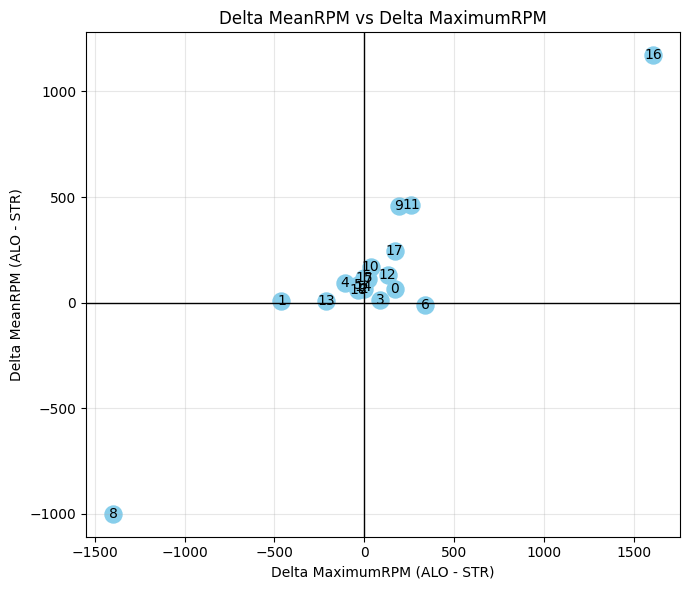

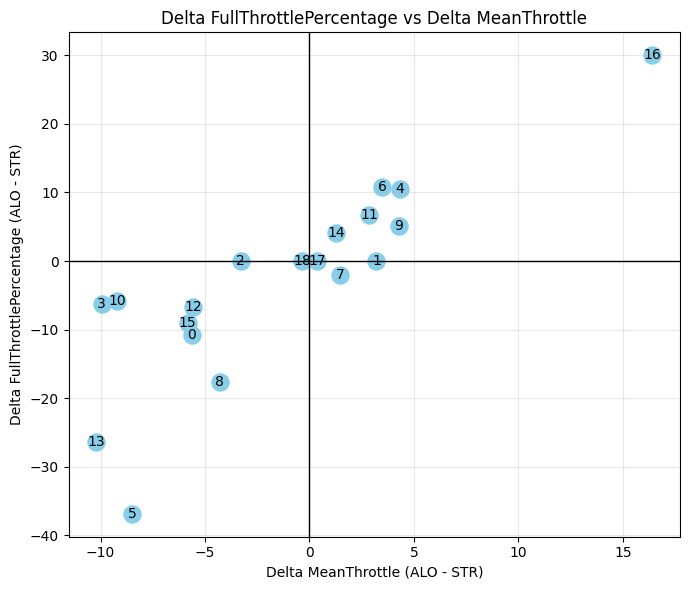

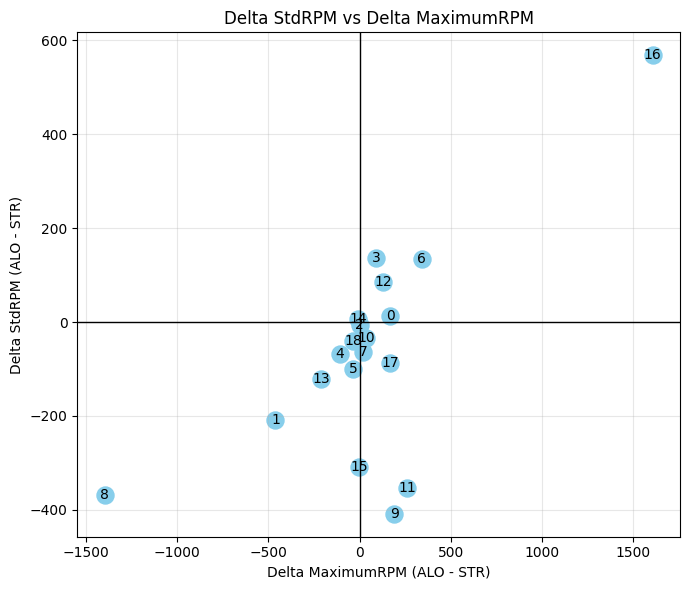

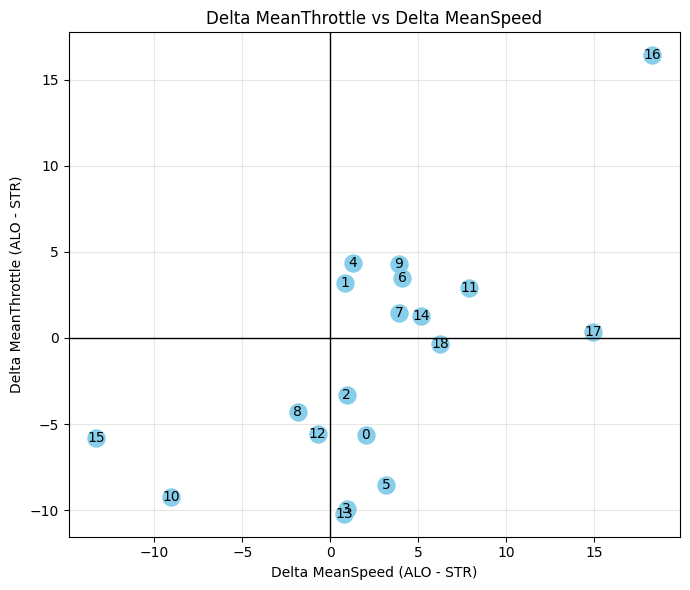

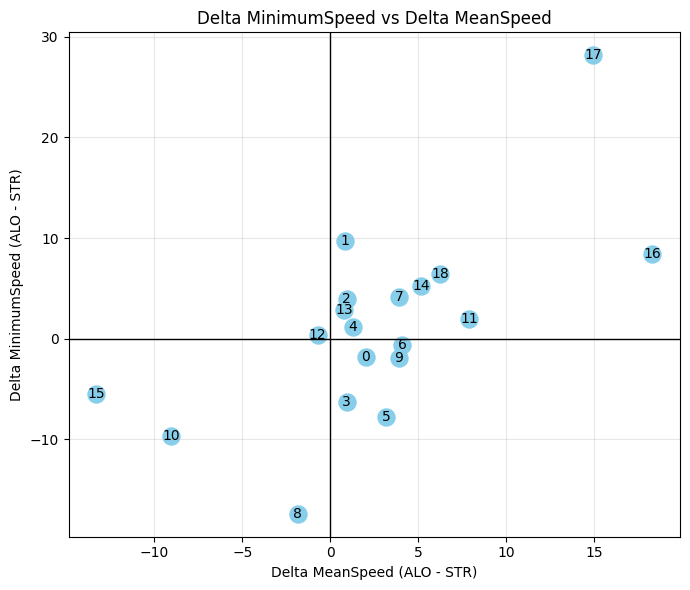

In [11]:
from itertools import combinations

segment_features = [
    column
    for column in lap_1["Segments"].columns
    if column not in ["Segment","SegmentTime", "NumberOfShifts", "LowestGear", "HighestGear"]
]

feature_correlations = []

for x_feature, y_feature in combinations(segment_features, 2):

    feature_correlations.append(
        calculate_feature_correlation(
            lap_1,
            lap_2,
            x_feature,
            y_feature,
        )
    )

feature_correlations = (
    pd.concat(feature_correlations, ignore_index=True)
    .sort_values("Pearson", key=lambda s: s.abs(), ascending=False)
    .reset_index(drop=True)
)

display(feature_correlations)
save_dataframe(
    feature_correlations,
    "SegmentFeaturesCorrelations",
    YEAR,
    GRAND_PRIX,
    TEAM,
)

top_relationships = (
    feature_correlations
    .head(5)[["FeatureX", "FeatureY"]]
    .values
)

for x_feature, y_feature in top_relationships:

    fig = scatterplot_features_relationship(
        lap_1,
        lap_2,
        x_feature,
        y_feature,
    )

    save_figure(
        fig,
        "features",
        "relationship",
        f"{x_feature.lower()}_{y_feature.lower()}",
        YEAR,
        GRAND_PRIX,
        TEAM,
        driver_1,
        driver_2,
    )

## Turns' Features and Turn Time Correlation Analysis

Turn features correlation with Turn Time:


,FeatureX,FeatureY,Pearson,PearsonP,Spearman,SpearmanP
0,ApexSpeed,TurnTime,-0.536950,0.021579,-0.519092,0.027279
1,EntrySpeed,TurnTime,-0.468864,0.049675,-0.048504,0.848430
2,BrakingPoint,TurnTime,0.269278,0.279897,0.244232,0.328719
3,BrakingDuration,TurnTime,-0.208508,0.406370,-0.388749,0.110853
4,BrakingDistance,TurnTime,-0.093893,0.710954,-0.280012,0.260418
5,ExitSpeed,TurnTime,0.047417,0.851790,-0.116615,0.644932


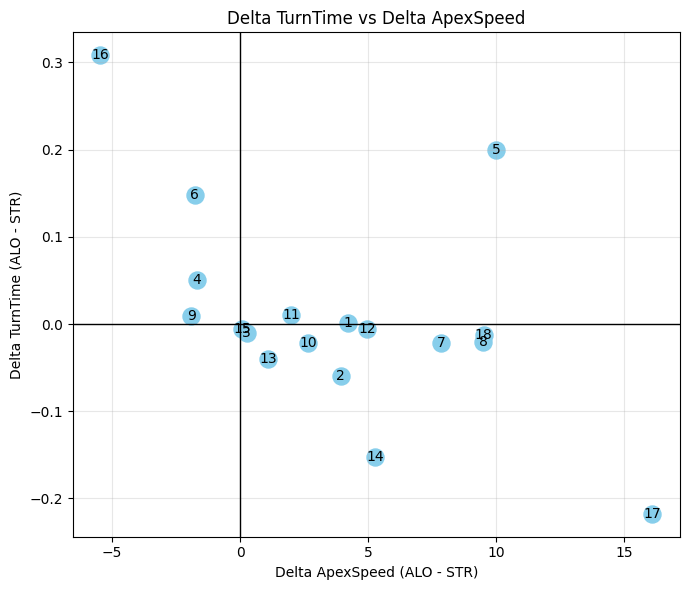

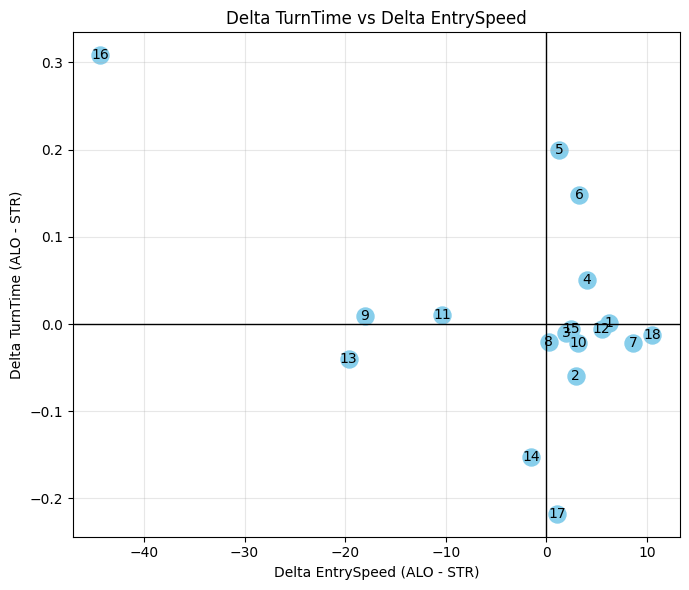

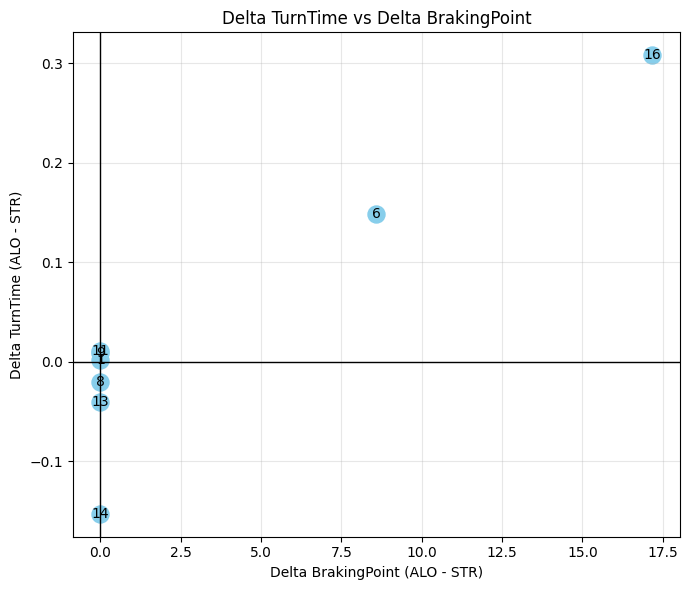

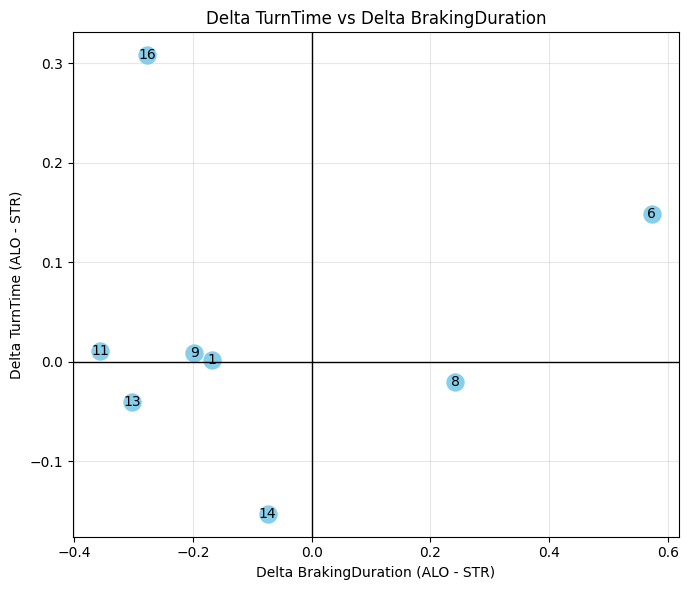

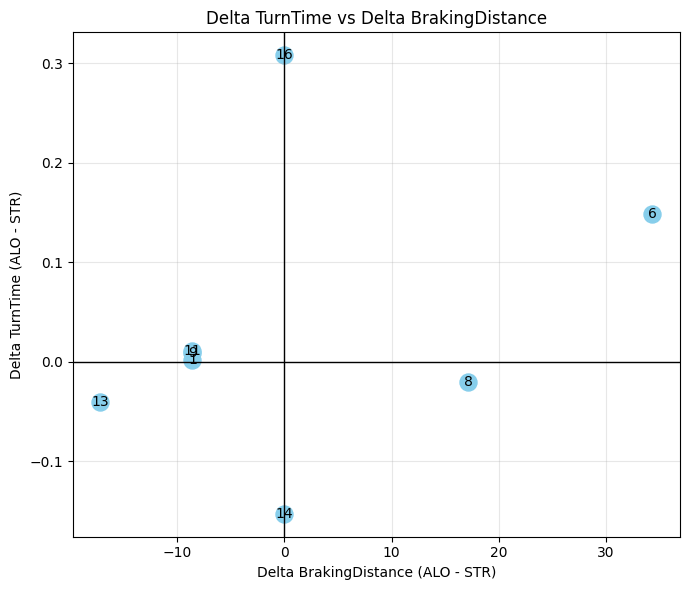

In [12]:
turn_features = [
    column
    for column in lap_1["Turns"].columns
    if column not in ["Turn", "TurnTime"]
]

turn_time_correlations = []

for feature in turn_features:

    turn_time_correlations.append(
        calculate_feature_correlation(
            lap_1,
            lap_2,
            feature,
            "TurnTime",
        )
    )

turn_time_correlations = (
    pd.concat(turn_time_correlations, ignore_index=True)
    .sort_values("Pearson", key=lambda s: s.abs(), ascending=False)
    .reset_index(drop=True)
)

print("Turn features correlation with Turn Time:")
display(turn_time_correlations)
save_dataframe(
    turn_time_correlations,
    "TurnTimeCorrelations",
    YEAR,
    GRAND_PRIX,
    TEAM,
)

top_features = (
    turn_time_correlations
    .head(5)["FeatureX"]
    .tolist()
)

for feature in top_features:

    fig = scatterplot_features_relationship(
        lap_1,
        lap_2,
        feature,
        "TurnTime",
    )

    save_figure(
        fig,
        "features",
        "relationship",
        f"{feature.lower()}_turntime",
        YEAR,
        GRAND_PRIX,
        TEAM,
        driver_1,
        driver_2,
    )

## Turns' Features Correlation Analysis

Investigate relationships between different performance metrics . Scatter plots here reveal how specific driving styles like early braking or throttle modulation correlate with exit speed and overall corner performance.

,FeatureX,FeatureY,Pearson,PearsonP,Spearman,SpearmanP
0,BrakingDistance,BrakingDuration,0.955408,6.832258e-10,0.919332,6.984252e-08
1,EntrySpeed,ExitSpeed,-0.633003,4.806960e-03,-0.517028,2.800615e-02
2,BrakingPoint,BrakingDistance,0.581072,1.144025e-02,0.510757,3.030952e-02
3,EntrySpeed,ApexSpeed,0.531940,2.307384e-02,0.298246,2.293224e-01
4,BrakingPoint,ApexSpeed,-0.481159,4.322317e-02,-0.518503,2.748474e-02
5,BrakingPoint,BrakingDuration,0.442726,6.578152e-02,0.319791,1.957875e-01
6,BrakingPoint,EntrySpeed,-0.306882,2.154654e-01,-0.121463,6.311480e-01
7,BrakingDuration,EntrySpeed,0.303136,2.214069e-01,0.375790,1.243292e-01
8,BrakingDuration,ExitSpeed,-0.165843,5.107462e-01,-0.181416,4.712548e-01
9,BrakingDuration,ApexSpeed,0.120270,6.345285e-01,0.210572,4.016323e-01


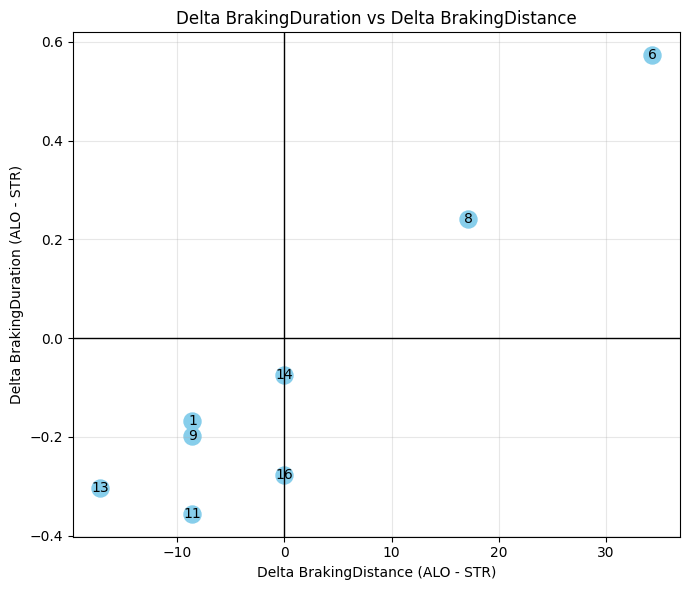

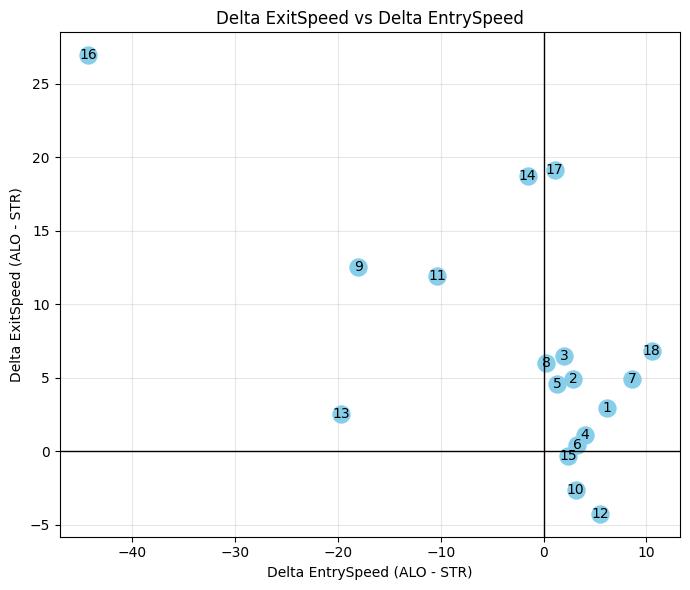

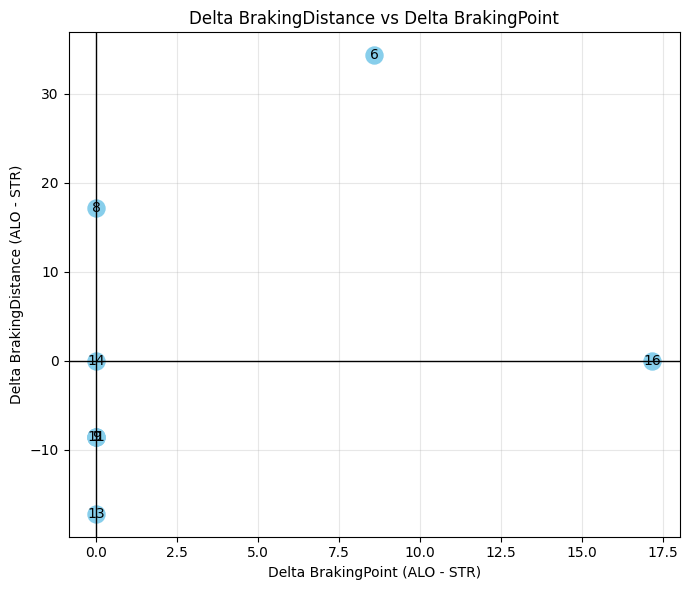

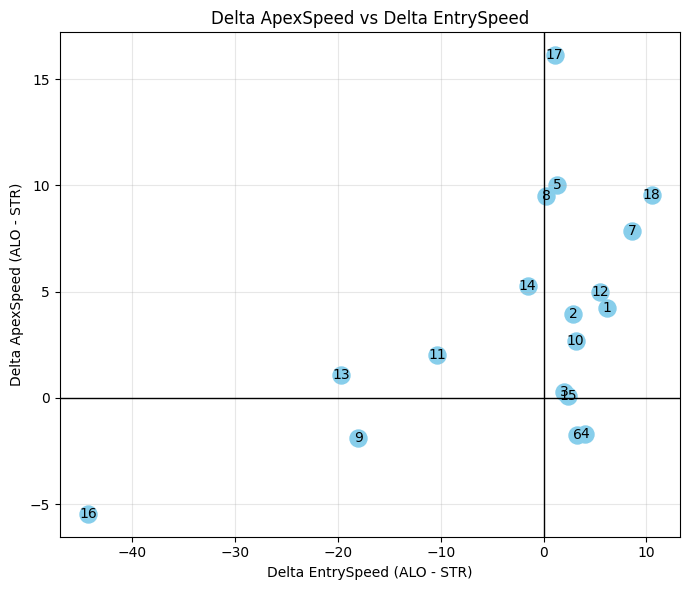

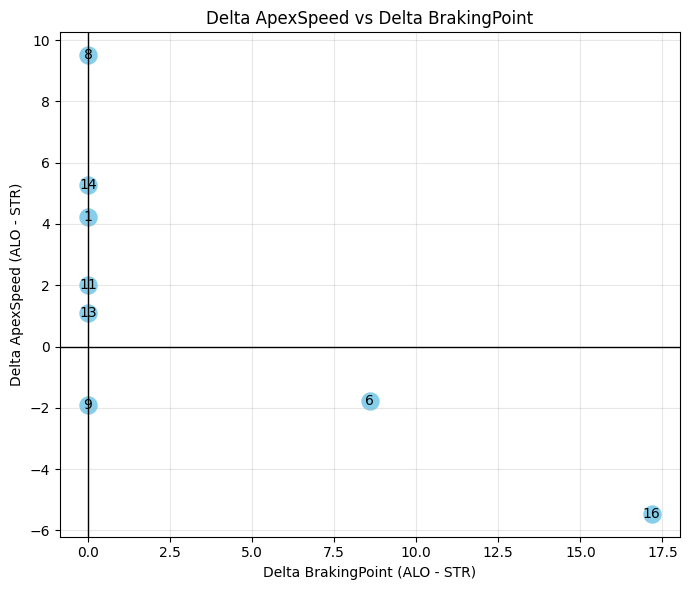

In [13]:
segment_features = [
    column
    for column in lap_1["Turns"].columns
    if column not in ["Turn","TurnTime"]
]

feature_correlations = []

for x_feature, y_feature in combinations(segment_features, 2):

    feature_correlations.append(
        calculate_feature_correlation(
            lap_1,
            lap_2,
            x_feature,
            y_feature,
        )
    )

feature_correlations = (
    pd.concat(feature_correlations, ignore_index=True)
    .sort_values("Pearson", key=lambda s: s.abs(), ascending=False)
    .reset_index(drop=True)
)

display(feature_correlations)
save_dataframe(
    feature_correlations,
    "TurnFeaturesCorrelations",
    YEAR,
    GRAND_PRIX,
    TEAM,
)

top_relationships = (
    feature_correlations
    .head(5)[["FeatureX", "FeatureY"]]
    .values
)

for x_feature, y_feature in top_relationships:

    fig = scatterplot_features_relationship(
        lap_1,
        lap_2,
        x_feature,
        y_feature,
    )

    save_figure(
        fig,
        "features",
        "relationship",
        f"{x_feature.lower()}_{y_feature.lower()}",
        YEAR,
        GRAND_PRIX,
        TEAM,
        driver_1,
        driver_2,
    )